In [11]:
#!/usr/bin/env python3

# Menyesuaikan path agar dapat mengimpor modul dari direktori utama (induk)
# tanpa mengubah struktur direktori proyek
import sys
sys.path.append('..')

# Mengimpor file module untuk melakukan sync semua file
# pada direktori utama (induk)
import module

In [12]:
import os
from pathlib import Path


# Sumber data utama
BASE_DATASOURCE_PATH=os.path.join(Path.home().as_posix(), "datasets", "anxiety_raw")

# Anotasi pada dataset anxiety_raw
BASE_ANNOTATION_PATH=os.path.join(BASE_DATASOURCE_PATH, "annotations.xlsx")


# Verifikasi apakah path benar ada atau tidak
assert os.path.exists(BASE_DATASOURCE_PATH), f"Path tidak ditemukan: {BASE_DATASOURCE_PATH}"
assert os.path.exists(BASE_ANNOTATION_PATH), f"Path tidak ditemukan: {BASE_ANNOTATION_PATH}"

print("Datasource path successfully set.")

Datasource path successfully set.


In [13]:
import re
import pandas as pd
import numpy as np


dfs = pd.read_excel(BASE_ANNOTATION_PATH, sheet_name=['before', 'after'], engine='openpyxl')

df_before = dfs['before']

target_before = np.array([
    "ahmad_rifqi_hendriansyah",
    # "akhmad_aakhif_athallah",
    # "haikal_muhammad_rafli",
    # "hizkia_elsadanta",
    # "key_firdausi_alfarel",
    # "aaisyah_nursalsabiil_ni_patriarti",
    # "achmad_anfasa_rabbany",
    # "dika_arie_arrifky",
    # "fabian_ananda_merdana",
    # "muhammad_khalid_atthoriq",
    # "nova_eliza_maharani"
])

# Memilah data yang sesuai dengan target
filtered_df_before = df_before[df_before['subject_name'].isin(target_before)]

# Ekstraksi nomor q dari filepath menggunakan regex
def extract_q_name(path: str):
    m = re.search(r'/q(\d+)(?:/|$)', path)
    return int(m.group(1)) if m else None

# Menambahkan kolom q_num berdasarkan ekstraksi dari filepath
df = filtered_df_before.copy()
df['q_num'] = df['filepath'].apply(extract_q_name)

# Mengurutkan data berdasarkan q_num dan subject_name
df_sorted_by_q = df.sort_values(by='q_num', na_position='last')
df_sorted = df.sort_values(by=['subject_name', 'q_num'], na_position='last')

df_sorted.head()

,subject_name,anxiety_level,filepath,q_num
68,ahmad_rifqi_hendriansyah,high,/home/inadio/datasets/anxiety_raw/before/anxie...,1
69,ahmad_rifqi_hendriansyah,high,/home/inadio/datasets/anxiety_raw/before/anxie...,2
65,ahmad_rifqi_hendriansyah,high,/home/inadio/datasets/anxiety_raw/before/anxie...,3
66,ahmad_rifqi_hendriansyah,high,/home/inadio/datasets/anxiety_raw/before/anxie...,4
67,ahmad_rifqi_hendriansyah,high,/home/inadio/datasets/anxiety_raw/before/anxie...,5


Melakukan komputasi pada beberapa subjek yang dipilih pada sheet before

W0000 00:00:1772939995.650368   73861 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1772939995.655132   73864 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772939995.667249   73881 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


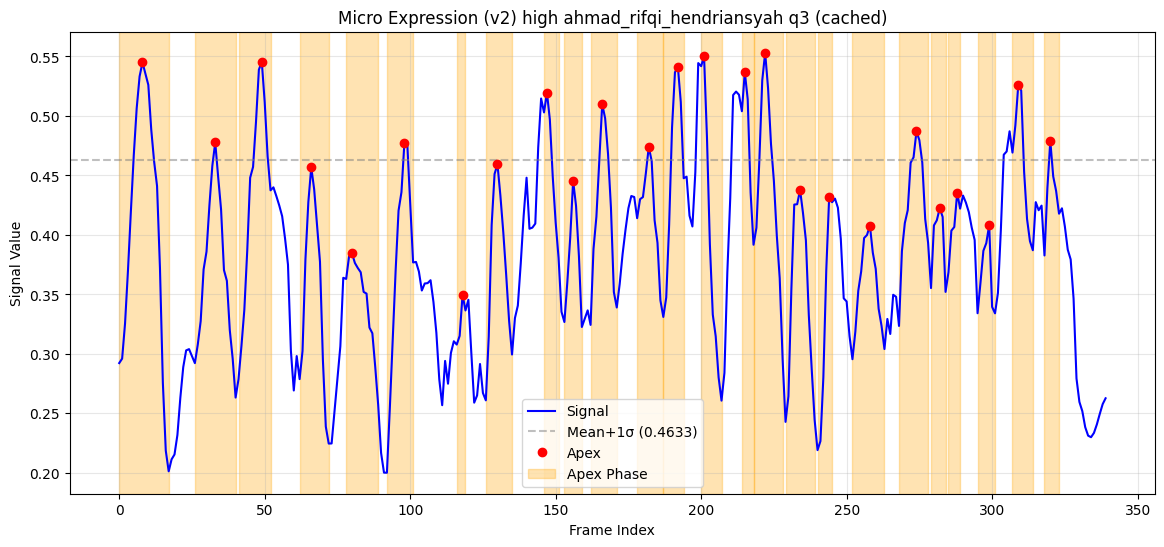

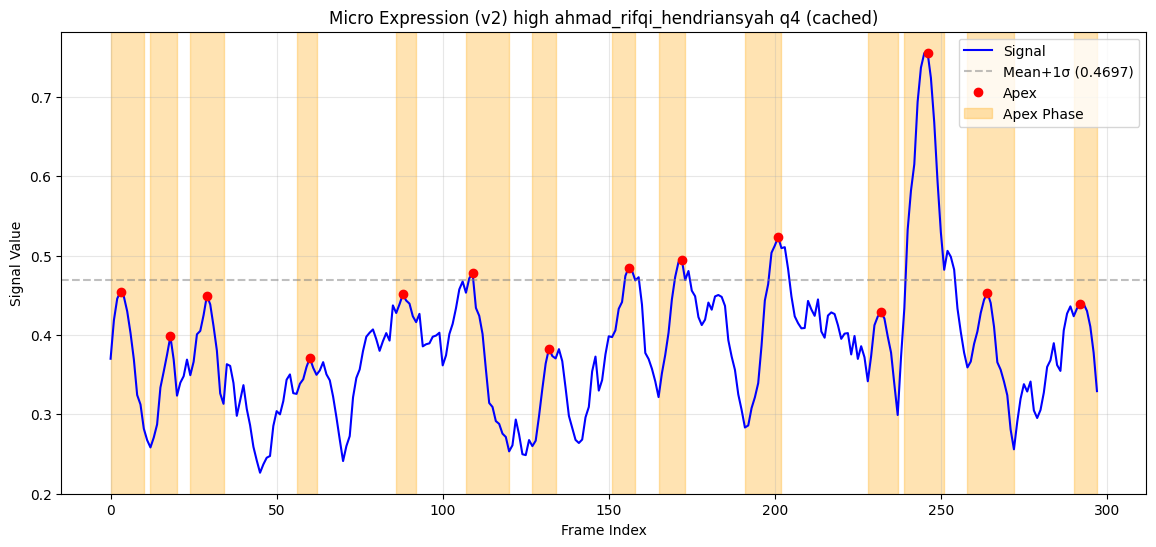

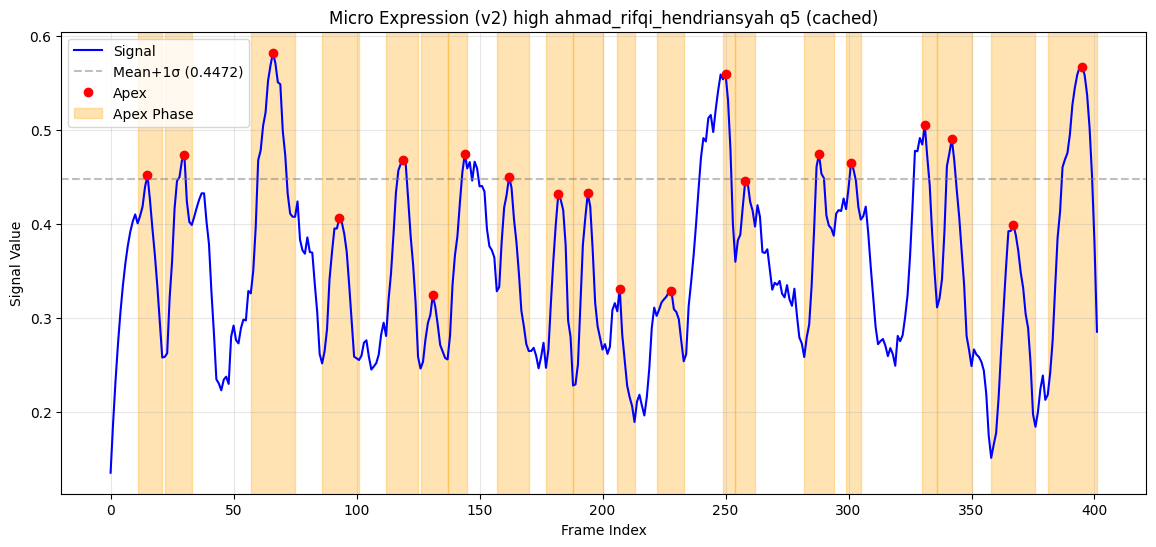

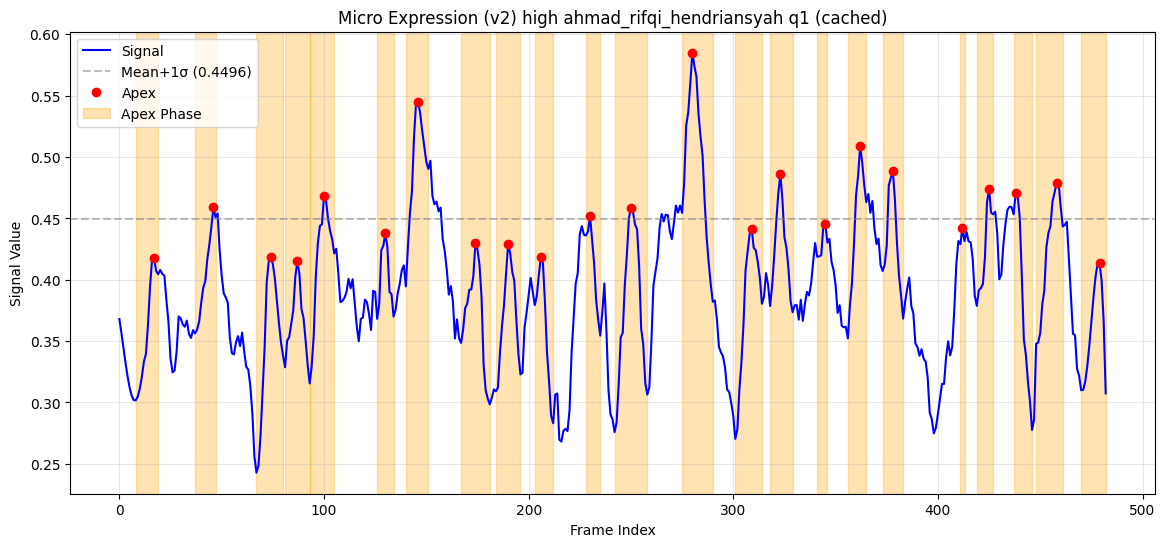

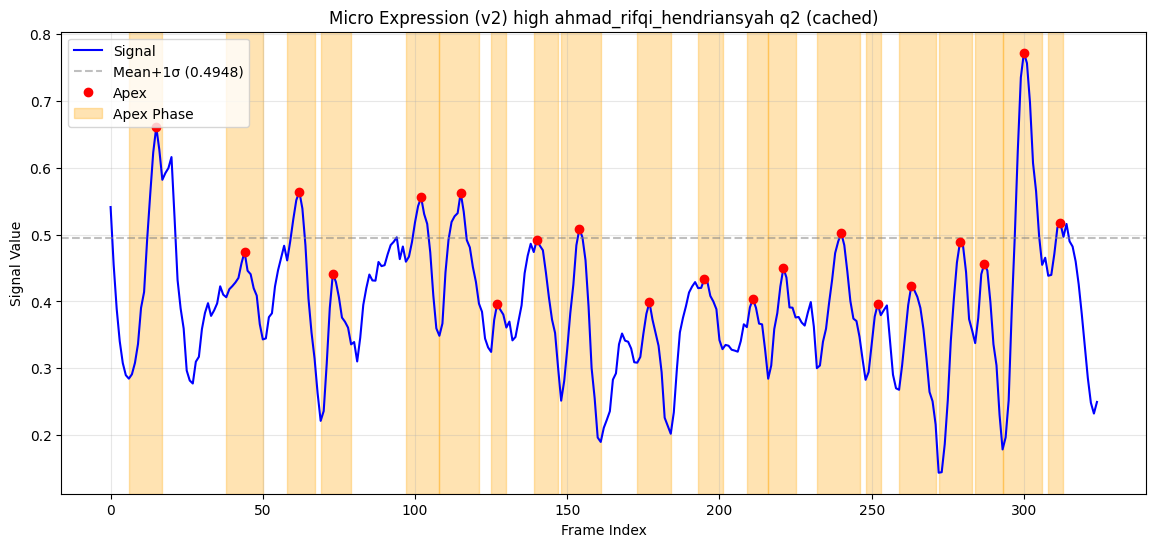

In [14]:
from src.apex.modules.v2 import ApexPhaseSpotter, ApexPhaseVisualizer, ApexSmoother


spotter = ApexPhaseSpotter(mode="single")

apex_phase = spotter.apex_phase

visualizer = ApexPhaseVisualizer()

for index, row in filtered_df_before.iterrows():

    video_path = os.path.join(BASE_DATASOURCE_PATH, row['filepath'])

    subject_name = row['subject_name']
    anxiety_level = row['anxiety_level']
    question_number = Path(video_path).parents[0].name

    output_file = os.path.join("..", ".output", f"{subject_name}_{question_number}_{anxiety_level}.npy")
    if os.path.exists(output_file):
        try:
            saved = np.load(output_file, allow_pickle=True)
        except Exception as e:
            print(f"Failed to load cached file {output_file}: {e}")
            continue

        if isinstance(saved, np.ndarray) and saved.dtype == object and saved.size == 4:
            saved_subject_name, saved_question, saved_level, saved_flow = saved.tolist()
            dx, dy, magnitudes = saved_flow
        elif isinstance(saved, (list, tuple)) and len(saved) == 4:
            saved_subject_name, saved_question, saved_level, saved_flow = saved
            dx, dy, magnitudes = saved_flow
        else:
            try:
                dx, dy, magnitudes = saved
            except Exception:
                print(f"Unrecognized cache format in {output_file}, skipping.")
                continue

        # smoothed = ApexSmoother.smooth(signal=magnitudes)

        apex_indices = apex_phase.find_apex(signal=magnitudes)

        phases = apex_phase.find_phase(signal=magnitudes, apex_indices=apex_indices)

        visualizer.plot_phases(signal=magnitudes,
                               phases=phases,
                               apex_indices=apex_indices,
                               title=f"Micro Expression (v2) {anxiety_level} {subject_name} {question_number} (cached)")
        continue

    # Video path yang akan diproses
    video_path = os.path.join(BASE_DATASOURCE_PATH, row['filepath'])

    # # Memproses video menggunakan apex phase spotter
    apex_indices, phases = spotter.process(video_path)

    # # Menyimpan magnitudes untuk setiap video yang diproses
    visualizer.plot_phases(signal=spotter.magnitudes,
                           phases=phases,
                           apex_indices=apex_indices,
                           title=f"Micro Expression (v2) {anxiety_level} {subject_name} {question_number}")
